### Strategy Stress Testing & Risk Analytics

In [158]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

In [159]:
data = pd.read_excel(r"E:\Quant_fin\Experiments\Risk Analysis\Stress_test\ledger_df.xlsx")

In [160]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8130 entries, 0 to 8129
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Symbol          8130 non-null   object        
 1   Datetime_Entry  8130 non-null   datetime64[ns]
 2   Qty             8130 non-null   int64         
 3   Price           8130 non-null   float64       
 4   Exit_date       8130 non-null   datetime64[ns]
 5   Exit_Price      8130 non-null   float64       
 6   PnL             8130 non-null   float64       
 7   equity_curve    8130 non-null   float64       
 8   max_roll        8130 non-null   float64       
 9   max_drawdown    8130 non-null   float64       
dtypes: datetime64[ns](2), float64(6), int64(1), object(1)
memory usage: 635.3+ KB


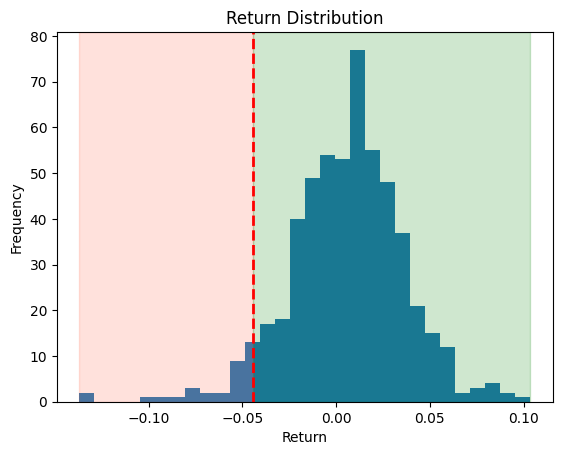

In [161]:
df_ = data.copy()
df_.set_index(pd.to_datetime(data['Exit_date']), inplace=True)
history_ = df_['equity_curve'].resample("W").last().pct_change()
low = history_.quantile(0.05)
plt.hist(history_, bins=30)
plt.title("Return Distribution")
plt.axvline(x=low, color='red', linestyle='--', linewidth=2, label=f'95% VaR: {low:.2%}')
plt.axvspan(xmin=history_.min(), xmax=low, color="tomato",alpha=0.19)
plt.axvspan(xmin=low, xmax=history_.max(), color="green",alpha=0.19)
plt.ylabel("Frequency")
plt.xlabel("Return")
plt.show()

In [162]:
def cagr(start_value, end_value, periods):
    return (end_value / start_value) ** (1 / periods) - 1
def volatility(equity_curve):
    trade_by_trade_volatility = equity_curve.pct_change().std()
    weekly_  = equity_curve.resample("W").last().pct_change().std() * np.sqrt(52)
    monthly_ = equity_curve.resample("M").last().pct_change().std() * np.sqrt(12)
    qtrly_ = equity_curve.resample("Q").last().pct_change().std() * np.sqrt(4)
    yearly_ = equity_curve.resample("Y").last().pct_change().std()
    return {
        "trade_by_trade_volatility":trade_by_trade_volatility,
        "weekly_volatility":weekly_,
        "monthly_volatility":monthly_,
        "qtrly_volatility":qtrly_,
        "yearly_volatility":yearly_

    }

    print(yearly_)
def sharp_ratio(rf, cagr, std):
    return (cagr-rf)/std
initial_capital = data['equity_curve'].iloc[0]#1_000_000
ending_value = data['equity_curve'].iloc[-1]
rf = 0.07
start_date  = data['Datetime_Entry'].min()
end_date = data['Exit_date'].max()
cagr_  = cagr(initial_capital, ending_value, int((end_date - start_date).days/365))
data.set_index(data['Exit_date'], inplace=True, drop=False)
volatility_ = volatility(data['equity_curve'])
max_drawdown = data['max_drawdown'].min()
sharp_ratio(cagr=cagr_,rf=rf,std=volatility_['yearly_volatility'])

np.float64(0.8726118425022599)

In [163]:
## Stress test  for slipage
## Is the strategy is profitable after considering the Slipage
slipage_stress = 0.001
data['Stressed_PNL'] = data['PnL']-((data['Exit_Price']*data['Qty'])+(data['Price']*data['Qty']))*slipage_stress
data['Stressed_EC'] = data['Stressed_PNL'].cumsum()+initial_capital

<Axes: xlabel='Exit_date'>

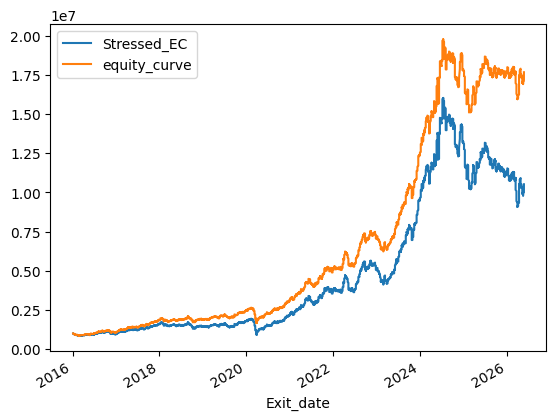

In [164]:
data[["Stressed_EC","equity_curve"]].plot()

In [165]:
import pdb
def  simulated_slipage_stress_test(df, lower_slipage, higher_slipage, initial_capital):
    initial_capital = df['equity_curve'].iloc[0]
    tt_ = ((df['Exit_Price']*df['Qty'])+(df['Price']*data['Qty']))
    ec = []
    cols = [float(round(a,4)) for a in list(np.arange(lower_slipage, higher_slipage, lower_slipage/10))]
    print(cols)
    for a in cols:
        slipage_stress = a
        Stressed_PNL = df['PnL']-tt_*slipage_stress
        ec.append(Stressed_PNL.cumsum()+initial_capital)   
    columns = [f"EC_{a}" for a in cols]
    ec_df = pd.concat(ec, axis=1)
    ec_df.columns = columns
    ec_df['Original'] = df['PnL'].cumsum()+initial_capital
    return ec_df
stressed = simulated_slipage_stress_test(data,0.0001,0.001,1000000)

[0.0001, 0.0001, 0.0001, 0.0001, 0.0001, 0.0002, 0.0002, 0.0002, 0.0002, 0.0002, 0.0002, 0.0002, 0.0002, 0.0002, 0.0002, 0.0002, 0.0003, 0.0003, 0.0003, 0.0003, 0.0003, 0.0003, 0.0003, 0.0003, 0.0003, 0.0004, 0.0004, 0.0004, 0.0004, 0.0004, 0.0004, 0.0004, 0.0004, 0.0004, 0.0004, 0.0004, 0.0005, 0.0005, 0.0005, 0.0005, 0.0005, 0.0005, 0.0005, 0.0005, 0.0005, 0.0006, 0.0006, 0.0006, 0.0006, 0.0006, 0.0006, 0.0006, 0.0006, 0.0006, 0.0006, 0.0006, 0.0007, 0.0007, 0.0007, 0.0007, 0.0007, 0.0007, 0.0007, 0.0007, 0.0007, 0.0008, 0.0008, 0.0008, 0.0008, 0.0008, 0.0008, 0.0008, 0.0008, 0.0008, 0.0008, 0.0008, 0.0009, 0.0009, 0.0009, 0.0009, 0.0009, 0.0009, 0.0009, 0.0009, 0.0009, 0.001, 0.001, 0.001, 0.001, 0.001]


In [166]:
import numpy as np


In [167]:
#The strategy yield profit even after slipge 
# but the return were less and it is accepatable

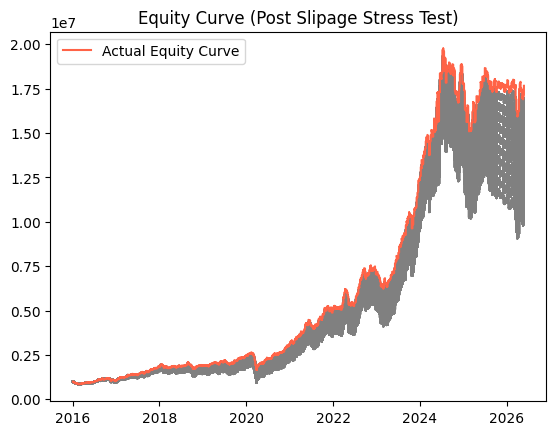

In [168]:
import matplotlib.pyplot as plt

plt.plot(stressed[[a for a in stressed.columns if "Ori" not in a]], 
         alpha=0.5, color = 'gray', )
plt.plot(stressed['Original'], color="tomato",
         label="Actual Equity Curve")
plt.legend()
plt.title("Equity Curve (Post Slipage Stress Test)")
plt.show()

CAGR


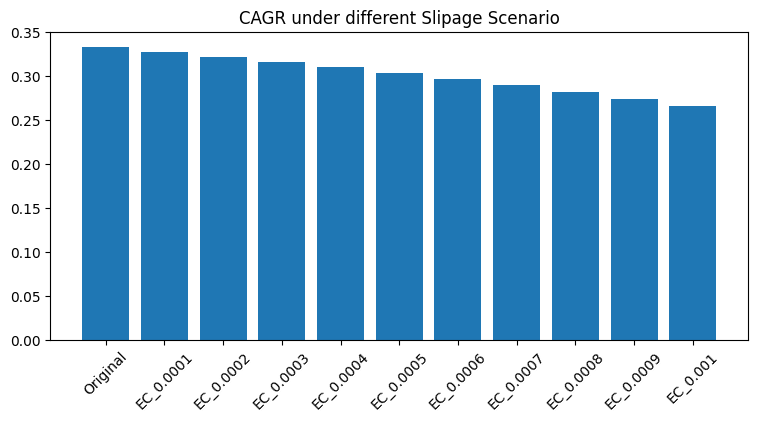

In [169]:
cagr = (stressed.iloc[-1] / stressed.iloc[0])**(1/10)-1
print("CAGR")
cagr = cagr.sort_values(ascending=False)#.head(15)
plt.figure(figsize=(9,4))
plt.bar(height=cagr.values, x=cagr.index)
plt.xticks(rotation=45)

plt.title("CAGR under different Slipage Scenario")
plt.show()

In [170]:
len(np.random.normal(.25,.16, len(stressed['Original'].pct_change()))),len(stressed['Original'].pct_change())

(8130, 8130)

In [171]:
low

np.float64(-0.04410390769908854)

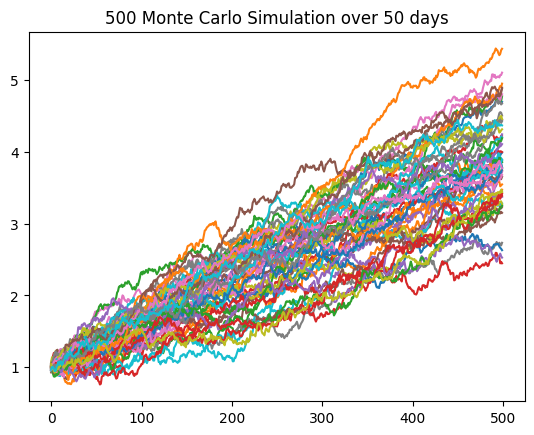

In [ ]:
import random
random.seed(15)
import scipy as spy
import numpy as np
np.random.seed(45)
mean = history_.mean()
std = history_.std()
n_days= 50
n_simulation  = 500
def monte_carlo_simulation(mean:float, std:float, n_days:int,n_simulation:int):
    returns = []
    for a in range(n_simulation):
        returns.append(np.random.normal(mean,std, n_days))
    return pd.DataFrame(returns)
simulated_return = monte_carlo_simulation(mean=mean, std=std, n_days=n_days,n_simulation=n_simulation)
simulated_equity_curve = simulated_return.cumsum()+1
for a in simulated_equity_curve.columns:
    plt.plot(simulated_equity_curve[a])
plt.title(f"{n_simulation} Simulation over {n_days} days")
plt.xlabel(f"MonteCarlo")
plt.show()

In [ ]:
from scipy.stats import shapiro

stat, p_value = shapiro(stressed['Original'].pct_change())
print(f"Shapiro-Wilk Statistic: {stat:.4f}, p-value: {p_value:.4f}")

if p_value > 0.05:
    print("Data appears to be Normally Distributed (Fail to reject H0)")
else:
    print("Data is NOT Normally Distributed (Reject H0)")

Shapiro-Wilk Statistic: nan, p-value: nan
Data is NOT Normally Distributed (Reject H0)


Fitted Parameters:
Degrees of Freedom (Fatness): 2.0532
Mean (Loc): 0.000152
Volatility (Scale): 0.002134
